# Thermal Infrared Simulation

Demonstration of thermal infrared radiative transfer with temperature-dependent surface emission.

In [1]:
from pyradtran.interface import PyRadtranAccessor  # This should register the accessor automatically
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pathlib import Path
import pandas as pd

config_path = Path('../config/thermal_config.yaml')
import logging
# change to "DEBUG" if you want to see more output
logging.getLogger('pyradtran').setLevel(logging.CRITICAL)

N_timesteps = 24

ds = xr.Dataset(
    coords={
        'time' : pd.date_range('2025-04-04T12:00:00', periods=N_timesteps, freq='s'),
        'latitude' : ('time', [51.3406321] * N_timesteps),
        'longitude' : ('time', [12.3747329] * N_timesteps),
        #'altitude' : ('time', [10] * N_timesteps),
    },
    data_vars={
        'surface_temperature' : ('time', np.linspace(300, 350, N_timesteps)),
    }
)

ds_sim = ds.pyradtran.run_uvspec(
    config_path=config_path,
    return_dataset=True,
    save_to_file=True,
    surface_temperature_var='surface_temperature',
)

print("\nSimulation complete!")
print(f"Dataset variables: {list(ds_sim.data_vars.keys())}")
print(f"Dataset coordinates: {list(ds_sim.coords.keys())}")
print(f"Dataset shape: {ds_sim.dims}")


Simulation complete!
Dataset variables: ['sza', 'edir', 'eglo', 'edn', 'eup', 'enet', 'albedo']
Dataset coordinates: ['time', 'latitude', 'longitude', 'altitude']
Dataset shape: FrozenMappingWarningOnValuesAccess({'time': 24, 'altitude': 10})


In [2]:
# right now, surface temperature is modified along the time dimension
# but unfortunately, surface_temperature is not passed down to ds_sim dataset...
surface_temperature = ds['surface_temperature']
ds_sim['surface_temperature'] = ds['surface_temperature']

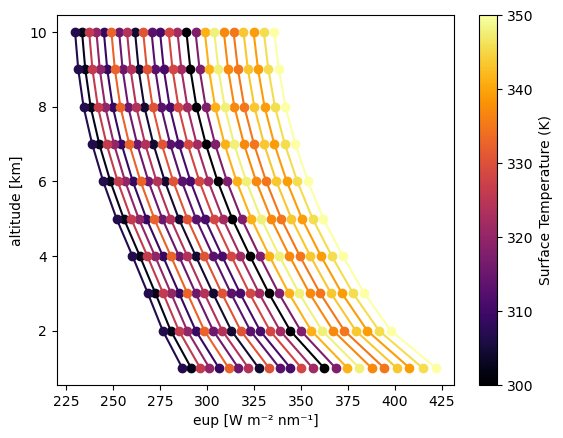

In [3]:
fig, ax = plt.subplots()

### change the prop cycle to inferno colors

ax.set_prop_cycle(color=plt.cm.inferno(np.linspace(0, 1, len(ds_sim['eup'].time))))

ds_sim['eup'].plot(ax=ax, hue='time', add_legend=False, marker='o', linestyle='-', label='EUP', y='altitude')

### add a colorbar instead of a legend

norm = plt.Normalize(ds_sim['surface_temperature'].min(), ds_sim['surface_temperature'].max())
sm = plt.cm.ScalarMappable(cmap=plt.cm.inferno, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, label='Surface Temperature (K)')


## Results

Thermal radiation field as function of wavelength and surface temperature.

In [4]:
ds_sim

<xarray.Dataset> Size: 14kB
Dimensions:              (time: 24, altitude: 10)
Coordinates:
  * time                 (time) datetime64[ns] 192B 2025-04-04T12:00:00 ... 2...
    latitude             (time) float64 192B 51.34 51.34 51.34 ... 51.34 51.34
    longitude            (time) float64 192B 12.37 12.37 12.37 ... 12.37 12.37
  * altitude             (altitude) int64 80B 1 2 3 4 5 6 7 8 9 10
Data variables:
    sza                  (time, altitude) float64 2kB 0.0 0.0 0.0 ... 0.0 0.0
    edir                 (time, altitude) float64 2kB 0.0 0.0 0.0 ... 0.0 0.0
    eglo                 (time, altitude) float64 2kB 148.4 130.9 ... 20.85
    edn                  (time, altitude) float64 2kB 148.4 130.9 ... 20.85
    eup                  (time, altitude) float64 2kB 362.2 344.3 ... 335.7
    enet                 (time, altitude) float64 2kB -213.9 -213.3 ... -314.9
    albedo               (time, altitude) float64 2kB 2.441 2.629 ... 14.25 16.1
    surface_temperature  (time) float64 192B 300.0 302.2 304.3 ... 347.8 350.0
Attributes:
    created:            2025-07-22T03:17:33.437021
    source:             PyRadtran
    output_type:        integrated_multi_altitude
    num_simulations:    24
    generated_by:       pyradtran
    pyradtran_version:  new_io_system